In [1]:
import numpy as np
import matplotlib.pyplot as plt
import datetime, time
import os, sys
import pandas as pd
from scipy.interpolate import interp1d

sys.path.append('../')
import NEXUSFunctions as nf

import matplotlib.dates as mdates
from   pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

In [2]:
run_t0s = {
    "NR23": datetime.datetime(2024, 3, 3,11,30, 0) , ## condensing time
    "NR22": datetime.datetime(2023, 9,30, 1,10, 0) , ## condensing time
    "NR21": datetime.datetime(2023, 7,31, 0,10, 0) , ## condensing time
    "NR18": datetime.datetime(2023, 3,17,20,14, 0) , ## condensing time
    "NR17": datetime.datetime(2023, 2,12,10,25, 0) , ## condensing time
    "NR15": datetime.datetime(2022,10,17,12,11,50) , ## condensing time
}

days_span = 8

In [3]:
def dt_to_plc_str(dt):
    return dt.strftime("%y%m%d")
                       
def dt_to_mmr_str(dt):
    return dt.strftime("%Y-%m-%d")

In [4]:
def pd_td_to_hrs(tdelta):
    return tdelta.total_seconds()/3600.

def pd_td_to_days(tdelta):
    return tdelta.total_seconds()/(24.*3600.)

In [5]:
series_mmr = { 
    k : nf.create_date_range(dt_to_mmr_str(v), days_span) 
    for k,v in run_t0s.items() 
}

offset_mmr = {
    k : datetime.timedelta(days=0, hours=0, minutes=0)
    for k,v in run_t0s.items() 
}

data_mmr = {
    k : nf.read_MACRT_data(series_mmr[k], offset_mmr[k])
    for k,v in run_t0s.items() 
}

time_mmr = {
    k : (data_mmr[k]['ctime']-v).apply(pd_td_to_days)
    for k,v in run_t0s.items() 
}

The starting date is: 
2024-03-03 00:00:00
The starting date is: 
2023-09-30 00:00:00
The starting date is: 
2023-07-31 00:00:00
The starting date is: 
2023-03-17 00:00:00
The starting date is: 
2023-02-12 00:00:00
The starting date is: 
2022-10-17 00:00:00


In [6]:
# series_plc = { 
#     k : nf.create_date_range(dt_to_plc_str(v), days_span, fmt="%y%m%d") 
#     for k,v in run_t0s.items() 
# }

# offset_plc = {
#     k : datetime.timedelta(days=0, hours=0, minutes=0)
#     for k,v in run_t0s.items() 
# }

# data_plc = {
#     k : nf.read_plclog_data(series_plc[k], offset_plc[k])
#     for k,v in run_t0s.items() 
# }

In [7]:
# NR22_time_mmr = (data_mmr_NR22['ctime']-NR22_t0).apply(pd_td_to_days)
# NR23_time_mmr = (data_mmr_NR23['ctime']-NR23_t0).apply(pd_td_to_days)

# NR22_time_plc = (data_plc_NR22['ctime']-NR22_t0).apply(pd_td_to_days)
# NR23_time_plc = (data_plc_NR23['ctime']-NR23_t0).apply(pd_td_to_days)

## Make the temperature plot

<IPython.core.display.Javascript object>


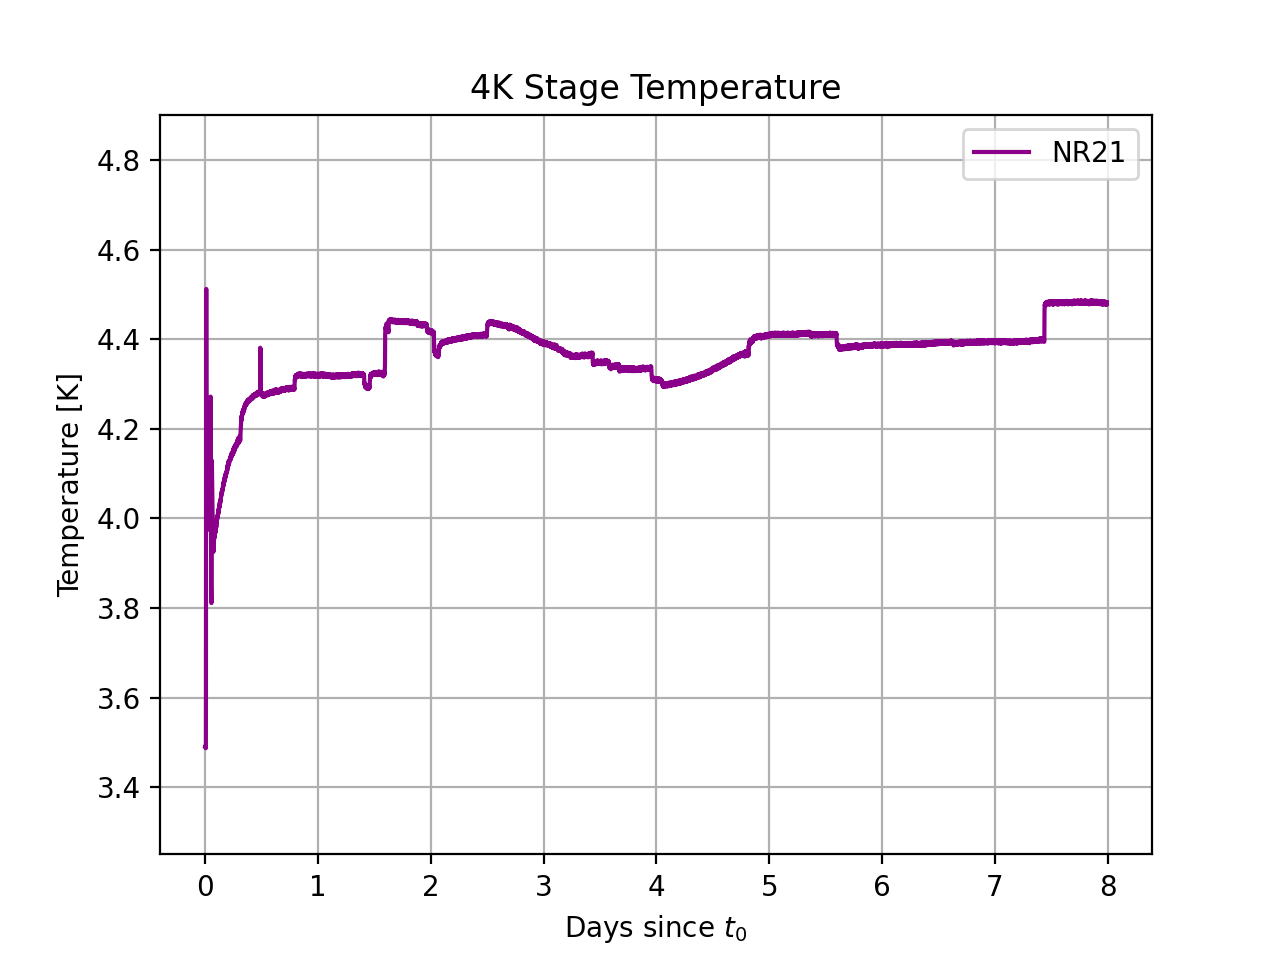

In [11]:
%matplotlib notebook
f = plt.figure()#figsize = (8,4), dpi=300)
a = plt.gca()
a.set_xlabel(r'Days since $t_0$')
a.set_ylabel('Temperature [K]')
a.set_title('4K Stage Temperature')

run_colors = ['dodgerblue', 'firebrick', 'darkmagenta', 'seagreen', 'goldenrod', 'navy']

for i,k in enumerate(data_mmr.keys()):
    
    if k != "NR21":
        continue
    
    run_data = data_mmr[k]
    
    a.plot( time_mmr[k][time_mmr[k]>=0] , run_data['2ND STAGE_Conv'][time_mmr[k]>=0] , color=run_colors[i], ls='-', label=k)
#     a.plot( time_mmr[k][time_mmr[k]>=0] , run_data['MIXING CHAMB_Conv'][time_mmr[k]>=0] , color=run_colors[i], ls='--', label="MC")

a.set_ylim([3.25,4.90])

plt.grid()
plt.legend(loc="best")